In [1]:
!git clone https://github.com/EnergyBasedFlowClassifier/EFC-package.git
%cd EFC-package
!pip install -r requirements.txt
!pip install --no-build-isolation .
%cd /content/EFC-package
!python setup.py build_ext --inplace
!pip install --no-build-isolation -e .

from google.colab import drive
import os
drive.mount("/content/drive", force_remount = True)
path = "/content/drive/My Drive/TCC/Dataset-final"
if os.path.isdir(path):
  !ls "{path}"
%cd /content/
!pip install optuna

fatal: destination path 'EFC-package' already exists and is not an empty directory.
/content/EFC-package
Processing /content/EFC-package
  Preparing metadata (setup.py) ... done
  Created wheel for efc: filename=efc-0.1.0-cp312-cp312-linux_x86_64.whl size=544839 sha256=5076b6e39cd9b6b04873db00550d6b93a6db3fe4af74410ff24a81a26cc83656
  Stored in directory: /root/.cache/pip/wheels/0d/56/b5/f8eb339887b622e9f026bccb9233add8bf358199a752a51d2a
Successfully built efc
  Attempting uninstall: efc
    Found existing installation: efc 0.1.0
    Uninstalling efc-0.1.0:
      Successfully uninstalled efc-0.1.0
/content/EFC-package
/usr/local/lib/python3.12/dist-packages/setuptools/dist.py:491: SetuptoolsDeprecationWarning: Invalid dash-separated options
!!

        ********************************************************************************
        Usage of dash-separated 'description-file' will not be supported in future
        versions. Please use the underscore name 'description_file' inste

In [2]:
from sklearn.ensemble import RandomForestClassifier, StackingClassifier, BaggingClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from efc import EnergyBasedFlowClassifier
from sklearn.metrics import f1_score
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [3]:
# Carrego o dataset
balanced_df_atack_category = pd.read_csv(f"{path}/balanced_df_atack_category.csv")

# Defino oq é saída e oq é entrada
X = balanced_df_atack_category.select_dtypes(include = np.number)
y = balanced_df_atack_category['Label']

# Codificação dos rótulos
le = LabelEncoder()
y_encoded = le.fit_transform(y)


In [4]:
balanced_df_atack_category

,Header_Length,Protocol_Type,Time_To_Live,Rate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,...,Tot_sum,Min,Max,AVG,Std,Tot_size,IAT,Number,Variance,Label
0,0.00,1,64.00,80120.420248,0.0,0.0,0.0,0.00,0.00,0.0,...,6000,60,60,60.00,0.000000,60.00,0.000013,100,0.000000,DDoS
1,8.00,17,64.00,76454.684652,0.0,0.0,0.0,0.00,0.00,0.0,...,6000,60,60,60.00,0.000000,60.00,0.000013,100,0.000000,DDoS
2,0.00,1,64.00,20488.003126,0.0,0.0,0.0,0.00,0.00,0.0,...,6000,60,60,60.00,0.000000,60.00,0.000049,100,0.000000,DoS
3,29.96,6,113.03,35.137120,0.0,0.0,0.0,0.30,0.93,0.0,...,10004,60,827,100.04,113.939459,100.04,0.029393,100,12982.200404,Benign
4,28.72,6,61.33,16.788267,0.0,0.0,0.0,0.41,0.89,0.0,...,8719,42,928,87.19,89.146196,87.19,0.059565,100,7947.044343,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47995,8.00,17,64.00,112.115090,0.0,0.0,0.0,0.00,0.00,0.0,...,2676,102,1226,267.60,342.840488,267.60,0.009197,10,117539.600000,Spoofing
47996,20.00,6,64.00,16028.370529,0.0,0.0,0.0,0.00,0.00,0.0,...,6000,60,60,60.00,0.000000,60.00,0.000062,100,0.000000,DoS
47997,0.00,1,64.00,57080.892760,0.0,0.0,0.0,0.00,0.00,0.0,...,6000,60,60,60.00,0.000000,60.00,0.000018,100,0.000000,DDoS
47998,30.32,6,64.02,16.674676,0.0,0.0,0.0,0.47,0.93,0.0,...,9631,66,929,96.31,91.910551,96.31,0.059971,100,8447.549394,Benign


In [5]:
sementes = np.linspace(10, 1000, 30, dtype = int)
sementes

array([  10,   44,   78,  112,  146,  180,  214,  248,  283,  317,  351,
        385,  419,  453,  487,  522,  556,  590,  624,  658,  692,  726,
        761,  795,  829,  863,  897,  931,  965, 1000])

In [6]:
resultados = []

for i,s in enumerate(sementes):
  print(f"Rodada {i+1} de {len(sementes)}.")

  X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size = 0.2, random_state = s, stratify = y_encoded)

  modelos_dict = {

      'EFC Padrão': EnergyBasedFlowClassifier(
          n_bins = 30,
          cutoff_quantile = 0.90,
          n_jobs = 1),

      'Random Forest': RandomForestClassifier(n_jobs = 1,random_state = s),

      'Floresta de EFCs (Ensemble EFC)': BaggingClassifier(
          estimator = EnergyBasedFlowClassifier(n_bins = 30, cutoff_quantile = 0.90, n_jobs = 1),
          n_estimators = 6,
          warm_start = True,
          max_samples = 0.7,
          max_features = 0.7,
          bootstrap = True,
          bootstrap_features = True,
          n_jobs = 1),

      'LightGBM': LGBMClassifier(
          n_estimators = 10,
          n_jobs = 1,
          objective = 'multiclass',
          num_class = 6,
          verbose = -1
      ),

      'Stacking (LGBM + EFC)': StackingClassifier(
          estimators = [
              ('lgbm', LGBMClassifier(n_estimators = 10, n_jobs = 1, objective = 'multiclass', num_class = 6, verbose = -1)),
              ('efc', EnergyBasedFlowClassifier(n_bins = 30, cutoff_quantile = 0.90, n_jobs = 1))
          ],
          final_estimator = LogisticRegression(),
          cv = 3,
          n_jobs = 1),

      'EFC TPE': EnergyBasedFlowClassifier(
          n_bins = 18,
          cutoff_quantile = 0.7668761175517792,
          pseudocounts = 0.5549765516061752,
          n_jobs = 1),

      'EFC GA': EnergyBasedFlowClassifier(
          n_bins = 15,
          cutoff_quantile = 0.7608545493385291,
          pseudocounts = 0.5148538589793428,
          n_jobs = 1),
  }

  for nome, modelo in modelos_dict.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    f1 = f1_score(y_test, y_pred, average = 'macro', zero_division = 0)

    resultados.append({'Modelo': nome, 'Macro F1': f1, 'Seed': s})

Rodada 1 de 30.
Rodada 2 de 30.
Rodada 3 de 30.
Rodada 4 de 30.
Rodada 5 de 30.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Rodada 6 de 30.
Rodada 7 de 30.
Rodada 8 de 30.
Rodada 9 de 30.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Rodada 10 de 30.
Rodada 11 de 30.


...

Rodada 21 de 30.
Rodada 22 de 30.
Rodada 23 de 30.
Rodada 24 de 30.
Rodada 25 de 30.
Rodada 26 de 30.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Rodada 27 de 30.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Rodada 28 de 30.
Rodada 29 de 30.
Rodada 30 de 30.


In [7]:
resultados

[{'Modelo': 'EFC Padrão',
  'Macro F1': 0.8629330327392016,
  'Seed': np.int64(10)},
 {'Modelo': 'Random Forest',
  'Macro F1': 0.9135518567935622,
  'Seed': np.int64(10)},
 {'Modelo': 'Floresta de EFCs (Ensemble EFC)',
  'Macro F1': 0.8638155598042278,
  'Seed': np.int64(10)},
 {'Modelo': 'LightGBM', 'Macro F1': 0.9247231708947882, 'Seed': np.int64(10)},
 {'Modelo': 'Stacking (LGBM + EFC)',
  'Macro F1': 0.9242173774631367,
  'Seed': np.int64(10)},
 {'Modelo': 'EFC TPE', 'Macro F1': 0.8995455622595151, 'Seed': np.int64(10)},
 {'Modelo': 'EFC GA', 'Macro F1': 0.8885637010153133, 'Seed': np.int64(10)},
 {'Modelo': 'EFC Padrão',
  'Macro F1': 0.8587238736658013,
  'Seed': np.int64(44)},
 {'Modelo': 'Random Forest',
  'Macro F1': 0.9199343742159941,
  'Seed': np.int64(44)},
 {'Modelo': 'Floresta de EFCs (Ensemble EFC)',
  'Macro F1': 0.7333294520574346,
  'Seed': np.int64(44)},
 {'Modelo': 'LightGBM', 'Macro F1': 0.9279064472398888, 'Seed': np.int64(44)},
 {'Modelo': 'Stacking (LGBM + EFC

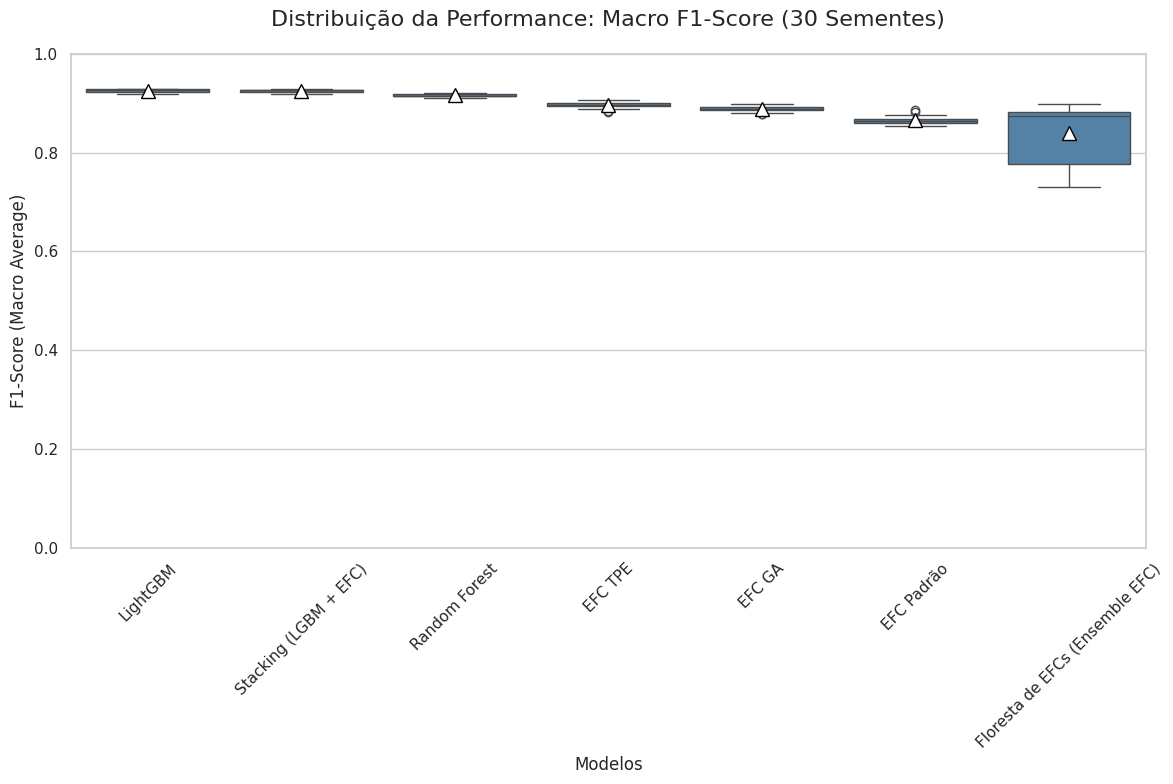

In [8]:
df_resultados = pd.DataFrame(resultados)

plt.figure(figsize = (12, 8))
sns.set_theme(style = "whitegrid")

# Ordenação por média
ordem_modelos = df_resultados.groupby('Modelo')['Macro F1'].mean().sort_values(ascending = False).index

sns.boxplot(
    data = df_resultados,
    x = 'Modelo',
    y = 'Macro F1',
    order = ordem_modelos,
    color = "steelblue",      # Define uma cor única para todos os boxes
    orient = 'v',
    showmeans = True,
    meanprops = {'marker': "^", 'markeredgecolor': 'black', 'markerfacecolor': 'white', "markersize": "10"}
)

plt.ylim(0, 1)
plt.title('Distribuição da Performance: Macro F1-Score (30 Sementes)', fontsize = 16, pad = 20)
plt.ylabel('F1-Score (Macro Average)', fontsize = 12)
plt.xlabel('Modelos', fontsize = 12)
plt.xticks(rotation = 45)     # Rotação para facilitar a leitura dos nomes
plt.tight_layout()
plt.show()